In [3]:
%matplotlib ipympl
from analysis.loaders import *
from config import *
from analysis.readout_dataset import *
from analysis.plotting import plot_single_iq_data
from analysis.plotting import plot_map
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider



Open the readout as a dataset:


In [4]:
qubit_name = 'q16'

data_sets = {
    'With TWPA': ReadoutDataset(qubit_name, with_twpa=True),
    'Without TWPA': ReadoutDataset(qubit_name, with_twpa=False)
}

Example of usecase of some of the inner dataset functions. Choose pulse length and amplitude and plot the IQ data...

Fidelity: 91.20 %
Separation: 2.00 a.u.
Gaussian Deviation: 16.66 a.u.


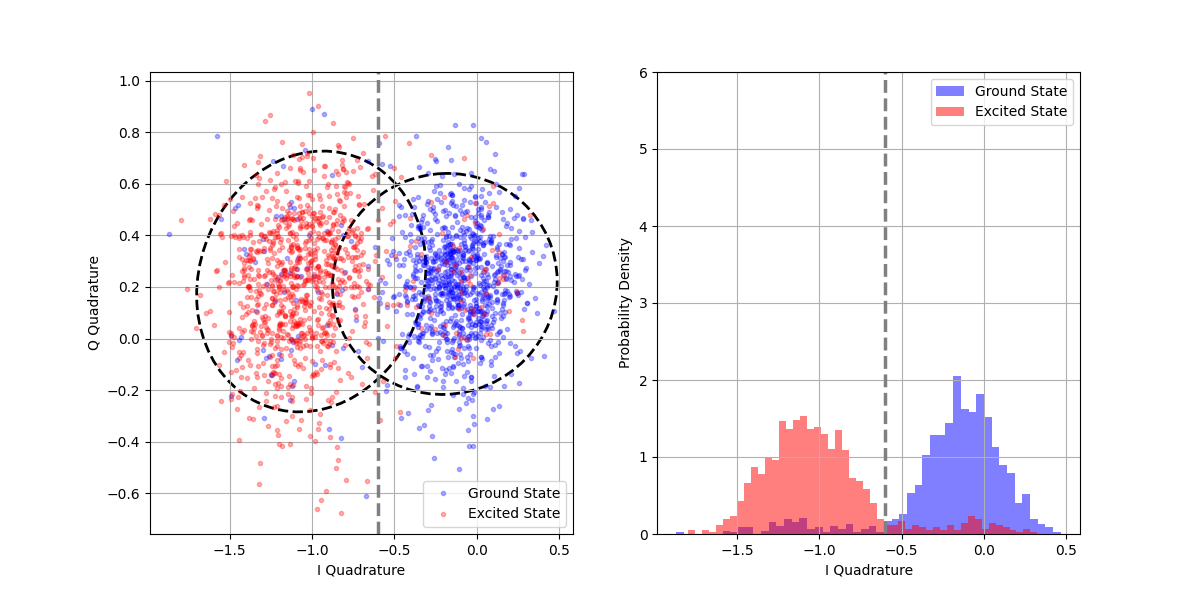

In [5]:
data_set = data_sets['With TWPA']

length, amplitude = data_set.find_max_fidelity_settings()

data_set.plot_single_iq_data(length=length/3, amplitude=amplitude/3, print=True)



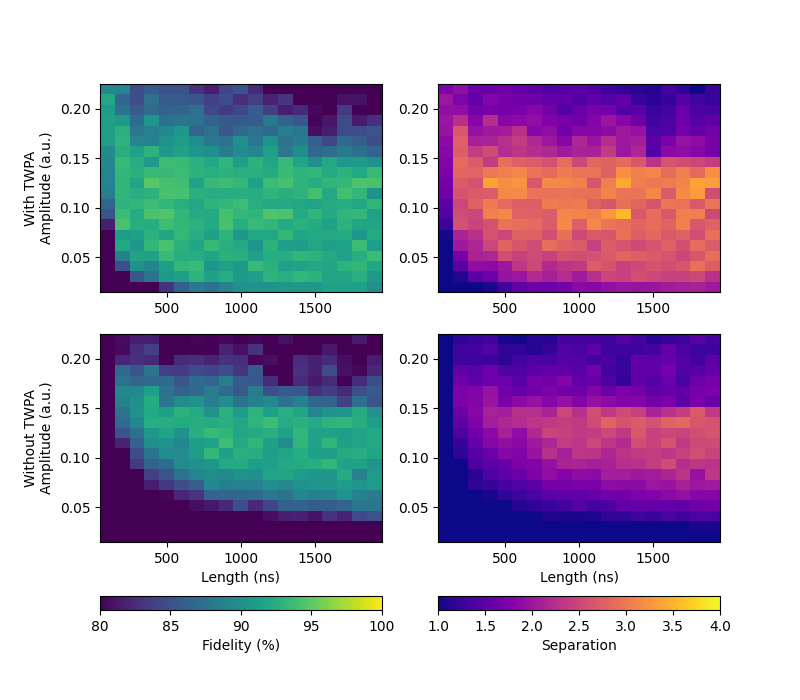

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(8, 7))

# twpa_options = ['Without TWPA', 'With TWPA']

twpa_options = ['With TWPA', 'Without TWPA']

for row, twpa_key in enumerate(twpa_options):

    data_set = data_sets[twpa_key]

    lengths = data_set.lengths
    amplitudes = data_set.amplitudes
    f_map = data_set.fidelity_map
    p_map = data_set.separation_map

    # ---- Fidelity Map ----
    # axs[row, 0].set_title(f"Fidelity Map {twpa_key} for {qubit_name}")
    c_fid = plot_map(
        axs[row, 0], lengths, amplitudes, 
        f_map.T, vmin=80, vmax=100
    )

    # ---- Separation Map ----
    # axs[row, 1].set_title(f"Separation Map {twpa_key} for {qubit_name}")
    c_sep = plot_map(
        axs[row, 1], lengths, amplitudes,
        p_map.T, vmin=1, vmax=4, cmap='plasma'
    )

    axs[row, 0].set_ylabel(f"{twpa_key}\nAmplitude (a.u.)")
    axs[1, 0].set_xlabel("Length (ns)")
    axs[1, 1].set_xlabel("Length (ns)")
# ---- COLORBARS ----

# LEFT COLUMN → Fidelity
cbar_left = fig.colorbar(
    axs[0, 0].collections[0],
    ax=axs[:, 0],
    orientation='horizontal',
    location='bottom',
    fraction=0.05,
    pad=0.1,
    label='Fidelity (%)'
)

# RIGHT COLUMN → Separation
cbar_right = fig.colorbar(
    axs[0, 1].collections[0],
    ax=axs[:, 1],
    orientation='horizontal',
    location='bottom',
    fraction=0.05,
    pad=0.1,
    label='Separation'
)

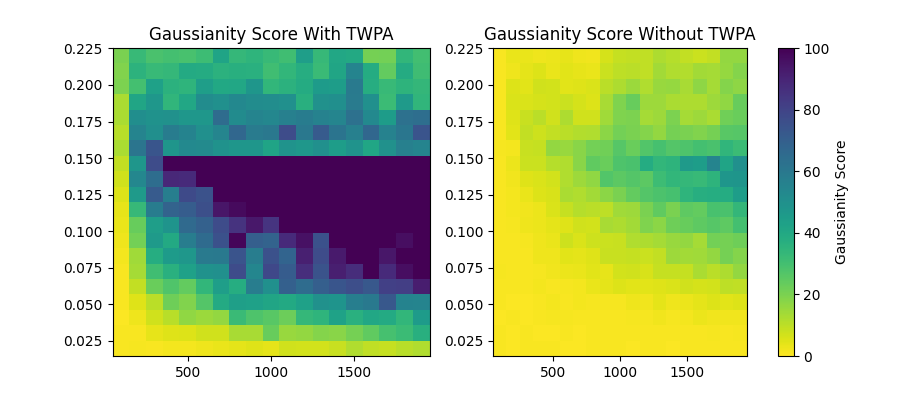

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4))


for i, (key, data_set) in enumerate(data_sets.items()):
    g = data_sets[key].gaussian_score_map
    c = plot_map(axs[i], lengths, amplitudes, g.T,
                 vmin=0, vmax=100, cmap='viridis_r')
    axs[i].set_title(f'Gaussianity Score {key}')

fig.colorbar(c, ax=axs[1], orientation='vertical',
             label='Gaussianity Score', pad=0.1, fraction=0.1,)

Output()

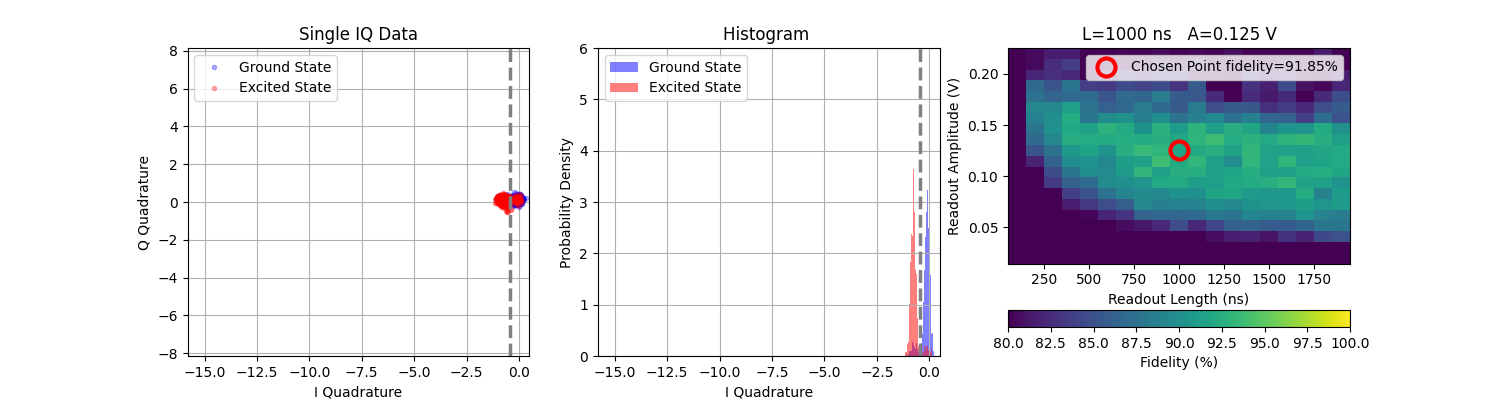

In [8]:

from matplotlib.pyplot import plot


def visulize():

    # ---- TWPA SWITCH ----
    twpa_switch = widgets.ToggleButtons(
        options=['Without TWPA', 'With TWPA'],
        value='Without TWPA',
        description='TWPA:',
        button_style=''
    )

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    data_set = data_sets['Without TWPA']
    
    c = data_set.plot_fidelity_map(
        ax=axs[2], point=(100e-9, 0.01), vmin=80, vmax=100)

    cbar = fig.colorbar(
        c, ax=axs[2], orientation='horizontal', label='Fidelity (%)'
    )

    fig.canvas.draw_idle()

    def ploti(l, a, scailing, twpa_option):
        # ---- INTERNAL PLOT FUNCTION ----
        for ax in axs:
            ax.clear()

        # pick dataset dynamically
        data_set = data_sets[twpa_option]

        # build figure
        base_xlim = 0.5

        data_set.plot_single_iq_data(
            length=l,
            amplitude=a,
            axs=axs[:2],
            plot=True,
            xlim=(-scailing-base_xlim, base_xlim),
            ylim=(-scailing/2-base_xlim, scailing/2+base_xlim)
        )

        c = data_set.plot_fidelity_map(
            ax=axs[2], point=(l, a), vmin=80, vmax=100)

        axs[0].set_title(f"Single IQ Data")
        axs[1].set_title(f"Histogram ")
        axs[2].set_title(f"L={l/1e-9:.0f} ns   A={a:.3f} V")

    # ---- INITIAL DATASET ----
    data_set = data_sets['Without TWPA']
    l_vals = data_set.lengths
    a_vals = data_set.amplitudes
    s_vals = np.linspace(0.01, 30, 50)

    # ---- SLIDERS ----
    l_slider = FloatSlider(
        value=l_vals[len(l_vals)//2],
        min=l_vals.min(),
        max=l_vals.max(),
        step=(l_vals[1] - l_vals[0]),
        description='Length (s)',
        readout_format='.2e',
        continuous_update=False
    )

    a_slider = FloatSlider(
        value=a_vals[len(a_vals)//2],
        min=a_vals.min(),
        max=a_vals.max(),
        step=(a_vals[1] - a_vals[0]),
        description='Amplitude',
        readout_format='.3f',
        continuous_update=False
    )

    s_slider = FloatSlider(
        value=s_vals[len(s_vals)//2],
        min=s_vals.min(),
        max=s_vals.max(),
        step=(s_vals[1] - s_vals[0]),
        description='Scaling',
        readout_format='.3f',
        continuous_update=False
    )

    # ---- UI LAYOUT ----
    ui = widgets.VBox([twpa_switch, l_slider, a_slider, s_slider])

    out = widgets.interactive_output(
        ploti,
        {
            'l': l_slider,
            'a': a_slider,
            'scailing': s_slider,
            'twpa_option': twpa_switch
        }
    )

    display(ui, out)


visulize()